In [3]:
from dotenv import load_dotenv

load_dotenv()

True

## Context Precision

In [ ]:
from openai import AsyncOpenAI
from ragas.llms import llm_factory
from langchain_openai import ChatOpenAI
from ragas.metrics.collections import ContextPrecision
import os

client = AsyncOpenAI(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
)


# llm = llm_factory("gpt-5-mini", client=client)

llm = llm_factory(
    "openai/gpt-oss-120b",
    client=client,
)

scorer = ContextPrecision(llm=llm) ### this variable is used in the next notebook to evaluate the RAG system's performance on context precision metric.

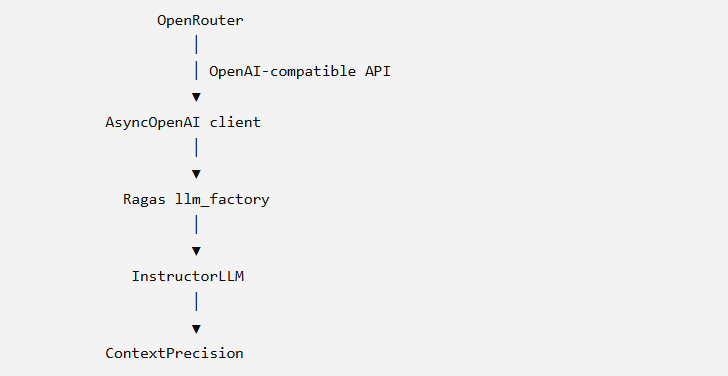

In [8]:
# Example 1 : Relevant context is first but two irrelevant chunks follow
result = await scorer.ascore(
    user_input="What is photosynthesis?",
    reference="Photosynthesis is the process by which plants use sunlight, water, and carbon dioxide to produce glucose and oxygen.",
    retrieved_contexts=[
        "Photosynthesis is the biological process through which plants convert sunlight and carbon dioxide into glucose and oxygen.",
        "Plants require water and minerals from the soil for growth.",
        "The Amazon rainforest is home to thousands of plant species."
    ]
)
print(f"Context Precision Score: {result.value}")

Context Precision Score: 0.9999999999


In [9]:
result

MetricResult(value=0.9999999999)

In [ ]:
# Example 2 : All retrieved contexts are relevant and support the reference answer
result = await scorer.ascore(
    user_input="Where is the Eiffel Tower located?",
    reference="The Eiffel Tower is located in Paris, France.",
    retrieved_contexts=[ 
        "The Eiffel Tower is located on the Champ de Mars in Paris, France.",
        "The Eiffel Tower was built in 1889 and stands 330 meters tall in Paris."
    ]
)
print(f"Context Precision Score: {result.value}")

Context Precision Score: 0.99999999995


In [10]:
# Example 3 : Two completely irrelevant chunks are ranked before the one relevant chunk
result = await scorer.ascore(
    user_input="What is the boiling point of water?",
    reference="Water boils at 100 degrees Celsius (212 degrees Fahrenheit) at sea level.",
    retrieved_contexts=[
        "The capital of France is Paris, a major European city known for the Eiffel Tower.",
        "The density of water is 1 gram per cubic centimeter at 4 degrees Celsius.",
        "Water boils at 100 degrees Celsius (212 degrees Fahrenheit) at standard atmospheric pressure."
    ]
)
print(f"Context Precision Score: {result.value}")

Context Precision Score: 0.3333333333
